<a href="https://colab.research.google.com/github/shreyash818/Seoul_Bike_project-/blob/main/Seoul_Bike.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libaray
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# read csv file
df = pd.read_csv('/content/drive/MyDrive/ASW Pandas/SeoulBikeData.csv',encoding='latin1')

In [ ]:
# Fist five recored
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [ ]:
# Check row and column in data
df.shape

(8760, 14)

In [ ]:
# Check NULL recored
df.isnull().sum()

,0
Date,0
Rented Bike Count,0
Hour,0
Temperature(°C),0
Humidity(%),0
Wind speed (m/s),0
Visibility (10m),0
Dew point temperature(°C),0
Solar Radiation (MJ/m2),0
Rainfall(mm),0


In [ ]:
# Aggergation of all Column
df.describe(include='all')

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
count,8760,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760,8760,8760
unique,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2,2
top,30/11/2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spring,No Holiday,Yes
freq,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2208,8328,8465
mean,NaN,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068,NaN,NaN,NaN
std,NaN,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746,NaN,NaN,NaN
min,NaN,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000,NaN,NaN,NaN
50%,NaN,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000,NaN,NaN,NaN
75%,NaN,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000,NaN,NaN,NaN


In [ ]:
# data Inforamtion
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

#**Variables Description**

**Date** - Tracks rental data over time for trend analysis

**Rented Bike Count**	- Main demand variable showing number of bikes rented

**Hour** -	Identifies peak and low rental hours

**Temperature(°C)**	- Measures weather impact on bike usage

**Humidity(%)**	- Shows air moisture effect on comfort and rentals

**Wind Speed(m/s)** -	Evaluates environmental influence on riding

**Visibility(10m)**	- Indicates weather clarity affecting safety

**Dew Point Temperature(°C)**	- Helps analyze advanced weather conditions

**Solar Radiation(MJ/m²)**	- Reflects sunlight impact on outdoor activity

**Rainfall(mm)** -	Explains drop in rentals during rain

**Snowfall(cm)** -	Supports winter demand analysis

**Seasons**	- Groups rentals based on seasonal patterns

**Holiday**	- Compares leisure vs working day demand

**Functioning Day** -	Shows service availability status





#**Seoul Bike Dataset — Visualization**

**1. Compare the average number of rented bikes across different seasons**

<Figure size 800x500 with 0 Axes>

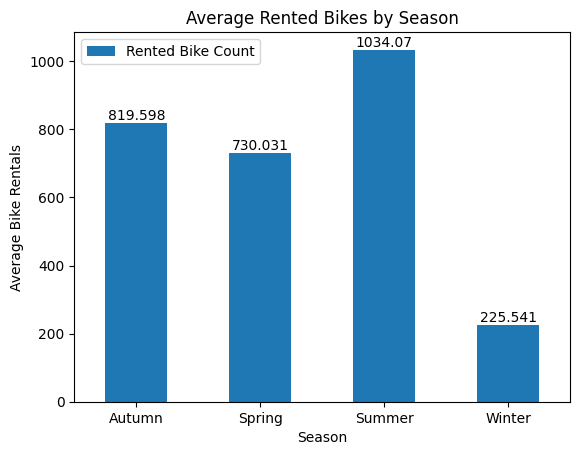

In [ ]:
season_avg = df.groupby('Seasons')['Rented Bike Count'].mean().reset_index()

plt.figure(figsize=(8,5))
ax = season_avg.plot(kind='bar',  x='Seasons')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Average Rented Bikes by Season')
plt.xlabel('Season')
plt.ylabel('Average Bike Rentals')
plt.xticks(rotation = 0)
plt.show()

**Q1 — Why did you pick this chart ?**

I chose a bar chart because it clearly compares average bike rentals across seasons. It makes it easy to see which season has higher or lower demand.

**Q2 — What insights were found ?**

The chart shows that bike rentals vary by season, indicating that some seasons have higher demand due to weather and outdoor activity preferences.

**Q3 — Business impact ?**

Yes, this insight helps the company plan bike availability and maintenance according to seasonal demand, improving service and revenue.

**2. Compare the total number of rented bikes on holiday vs non-holiday days**

<Figure size 700x500 with 0 Axes>

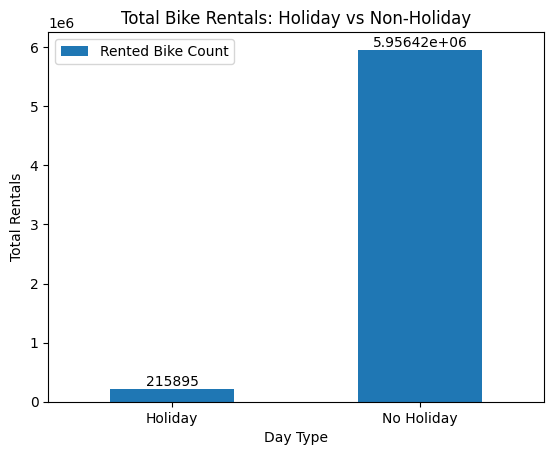

In [ ]:
holiday_total = df.groupby('Holiday')['Rented Bike Count'].sum().reset_index()

plt.figure(figsize=(7,5))
ax = holiday_total.plot(kind='bar', x='Holiday', y='Rented Bike Count')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Total Bike Rentals: Holiday vs Non-Holiday')
plt.xlabel('Day Type')
plt.ylabel('Total Rentals')
plt.xticks(rotation=0)
plt.show()

**Q1 — Why did you pick this chart ?**

A bar chart is ideal for comparing total rentals between holiday and non-holiday days, making the difference easy to interpret.

**Q2 — What insights were found ?**

The chart reveals whether people rent more bikes on holidays or regular days, highlighting user behavior patterns.

**Q3 — Business impact ?**

Yes, the company can adjust staffing, promotions, and bike distribution based on demand patterns to maximize efficiency and revenue.

**3. Show the distribution of total bike rentals across seasons**

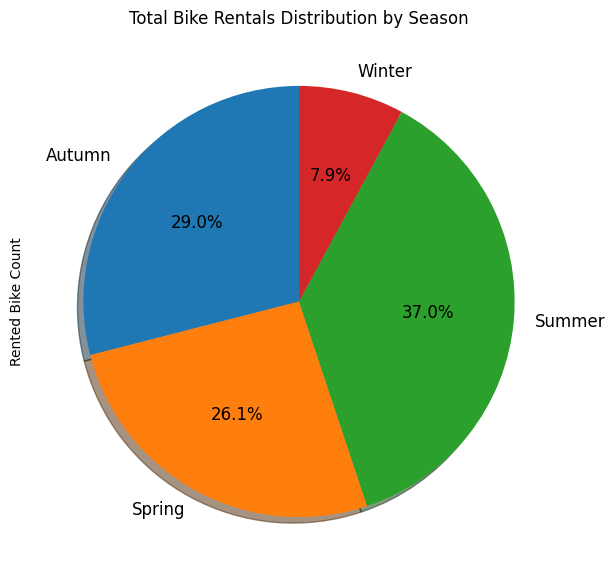

In [ ]:
season_total = df.groupby('Seasons')['Rented Bike Count'].sum()

# Step 2 — pie chart
plt.figure(figsize=(7,7))
season_total.plot(kind='pie', autopct='%1.1f%%', startangle=90, shadow=True, fontsize=12)
plt.title('Total Bike Rentals Distribution by Season')
plt.show()

**Q1 — Why did you pick this chart ?**

I chose a pie chart because it effectively shows how total bike rentals are distributed across seasons, making proportional comparison easy.

**Q2 — What insights were found ?**

The chart highlights which seasons contribute the most to total rentals, indicating seasonal demand patterns.

**Q3 — Business impact ?**

Yes, this helps the company plan seasonal inventory, maintenance, and marketing strategies to maximize revenue.

**4. Show the percentage distribution of functioning vs non-functioning days**

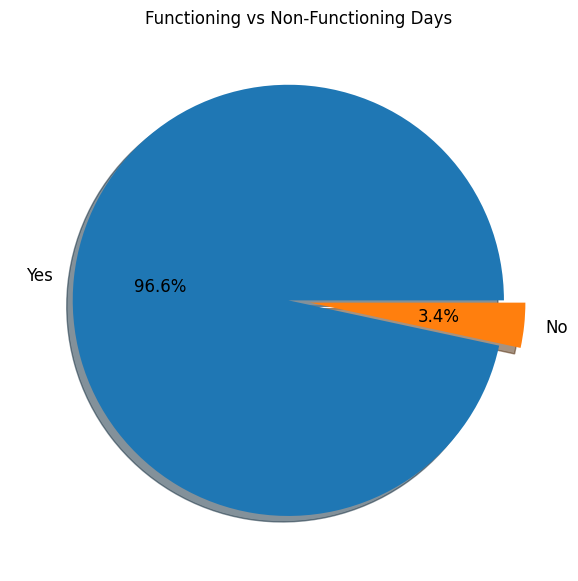

In [ ]:
func_count = df['Functioning Day'].value_counts()

# Step 2 — pie chart
plt.figure(figsize=(7,7))
func_count.plot(kind='pie',autopct='%1.1f%%',shadow=True,fontsize=12,explode=(0.05, 0.05))
plt.title('Functioning vs Non-Functioning Days')
plt.ylabel(" ")
plt.show()

**Q1 — Why did you pick this chart ?**

A pie chart is ideal to display percentage distribution, clearly showing the share of functioning versus non-functioning days.

**Q2 — What insights were found ?**

The chart shows how often bike services are operational, helping understand service availability patterns.

**Q3 — Business impact ?**

Yes, insights can help improve operational planning and reduce downtime, leading to better customer satisfaction and revenue.

**5. Create a count plot to show how many records belong to each season in the dataset.**

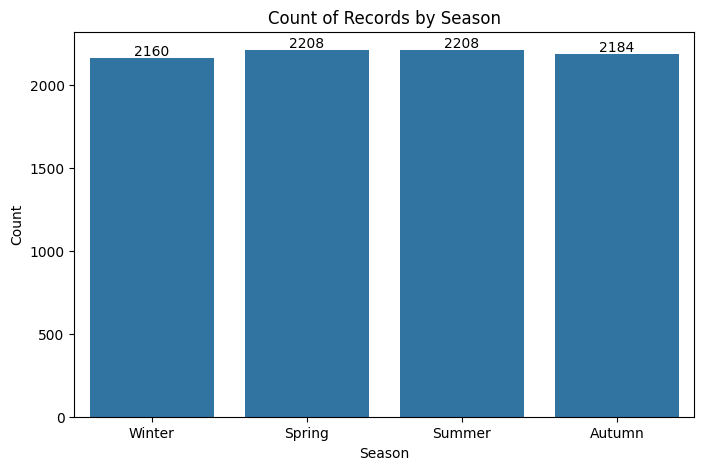

In [ ]:
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x='Seasons')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Count of Records by Season')
plt.xlabel('Season')
plt.ylabel('Count')
plt.show()

**Q1 — Why did you pick this chart?**

I chose a count plot because it directly shows the frequency of each season in the dataset, making category comparison simple.

**Q2 — What insights were found?**

The chart reveals how evenly or unevenly the dataset is distributed across seasons.

**Q3 — Business impact ?**

Yes, understanding seasonal distribution helps ensure fair analysis and planning based on data coverage.

**6. Create a count plot to show the number of holiday vs non-holiday records in the dataset.**

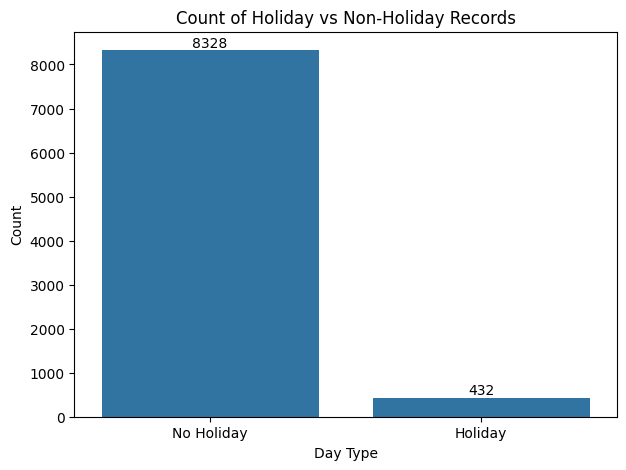

In [ ]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='Holiday')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Count of Holiday vs Non-Holiday Records')
plt.xlabel('Day Type')
plt.ylabel('Count')
plt.show()

**Q1 — Why did you pick this chart?**

I chose a count plot because it clearly shows how frequently holiday and non-holiday records appear, making comparison straightforward.

**Q2 — What insights were found?**

The chart reveals whether the dataset contains more regular days or holidays, helping understand data composition.

**Q3 — Business impact ?**

Yes, understanding day distribution supports better demand analysis and operational planning.

**Q7 .Create a line chart showing the average number of rented bikes for each hour of the day.**

<Figure size 1000x900 with 0 Axes>

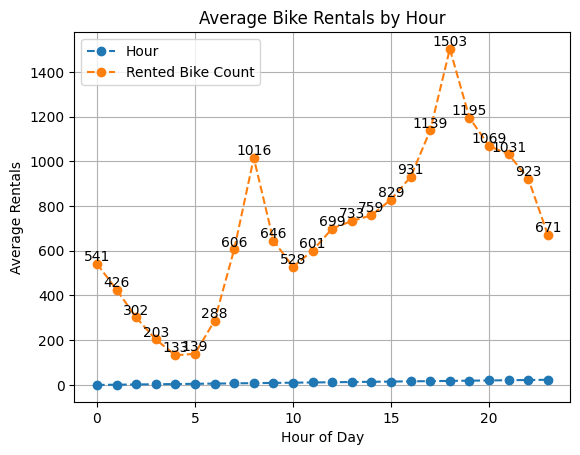

In [ ]:
avg_bike = df.groupby('Hour')['Rented Bike Count'].mean().reset_index()

plt.figure(figsize=(10,9))
ax = avg_bike.plot(kind='line', marker='o', linestyle='--')
# Marker labal
for x, y in zip(avg_bike['Hour'], avg_bike['Rented Bike Count']):
    ax.text(x, y, f'{y:.0f}', ha='center', va='bottom')

plt.title('Average Bike Rentals by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Rentals')
plt.grid()
plt.show()

**Q1 — Why did you pick this chart?**

I chose a line chart because it is ideal for showing trends over time. It clearly visualizes how bike rentals change throughout the day.

**Q2 — What insights were found?**

The chart reveals peak rental hours and low-demand periods, indicating when people are most likely to rent bikes.

**Q3 — Business impact ?**

Yes, the company can allocate bikes and staff efficiently during peak hours, improving service availability and revenue.

**Q8. Create a histogram to visualize the distribution of temperature values.**

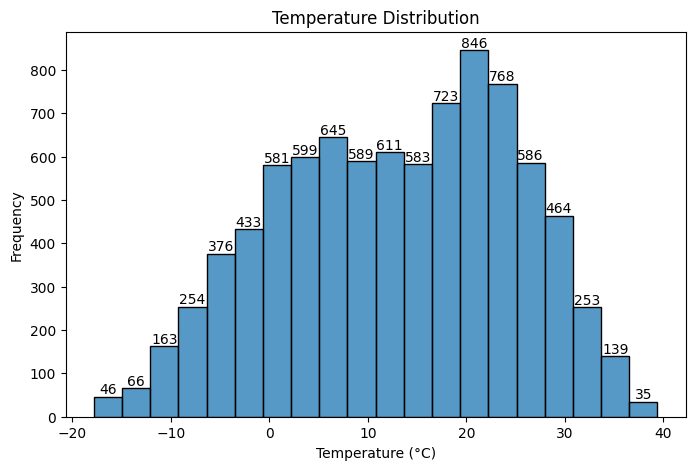

In [ ]:
plt.figure(figsize=(8,5))
ax = sns.histplot(df['Temperature(°C)'],bins=20,edgecolor='black')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Temperature Distribution')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.show()


**Q1 — Why did you pick this chart?**

I chose a histogram because it is best for showing how numerical values are distributed across ranges, making patterns easy to observe.

**Q2 — What insights were found?**

The chart reveals how temperature values are spread, including common ranges and possible extreme values.

**Q3 — Business impact ?**

Yes, understanding temperature distribution helps analyze how weather conditions influence bike rental demand.

**Q9. Create a histogram to visualize the distribution of rented bike counts.**

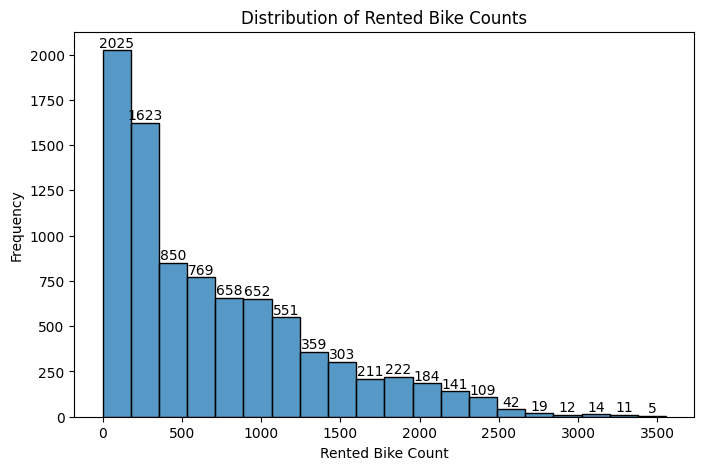

In [ ]:
plt.figure(figsize=(8,5))
ax = sns.histplot(df['Rented Bike Count'], bins=20)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Distribution of Rented Bike Counts')
plt.xlabel('Rented Bike Count')
plt.ylabel('Frequency')
plt.show()
# 2025 ase divas ahe jay made maja 0-200 baki rent zala hot

**Q1 — Why did you pick this chart?**

I chose a histogram because it effectively shows how rental counts are distributed across value ranges, making frequency patterns easy to interpret.

**Q2 — What insights were found?**

The chart reveals common rental ranges, peak frequency zones, and possible extreme demand periods.

**Q3 — Business impact ?**

Yes, understanding rental distribution helps predict demand levels and optimize bike allocation.

**10. Create a scatter plot to analyze the relationship between temperature and rented bike counts.**

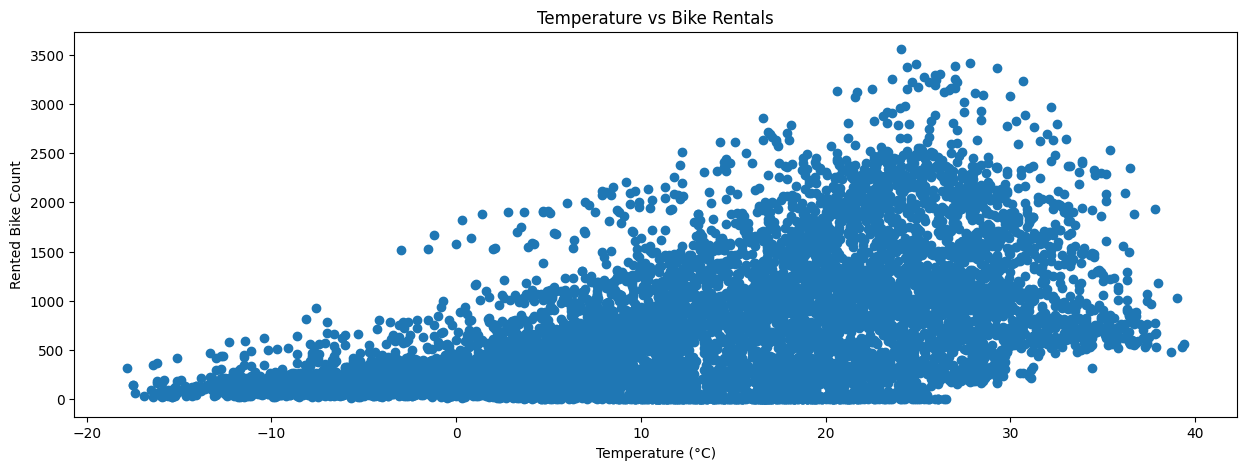

In [5]:
plt.figure(figsize=(15,5))
plt.scatter(df['Temperature(°C)'], df['Rented Bike Count'])

plt.title('Temperature vs Bike Rentals')
plt.xlabel('Temperature (°C)')
plt.ylabel('Rented Bike Count')

plt.show()


**Q1 — Why did you pick this chart?**

I chose a scatter plot because it is ideal for visualizing relationships between two numeric variables.

**Q2 — What insights were found?**

The chart shows how bike rentals change with temperature, revealing positive or negative trends.

**Q3 — Business impact ?**

Yes, understanding environmental impact helps improve demand forecasting and operational planning.

**11. Create a heatmap to visualize the correlation between numeric variables in the dataset.**

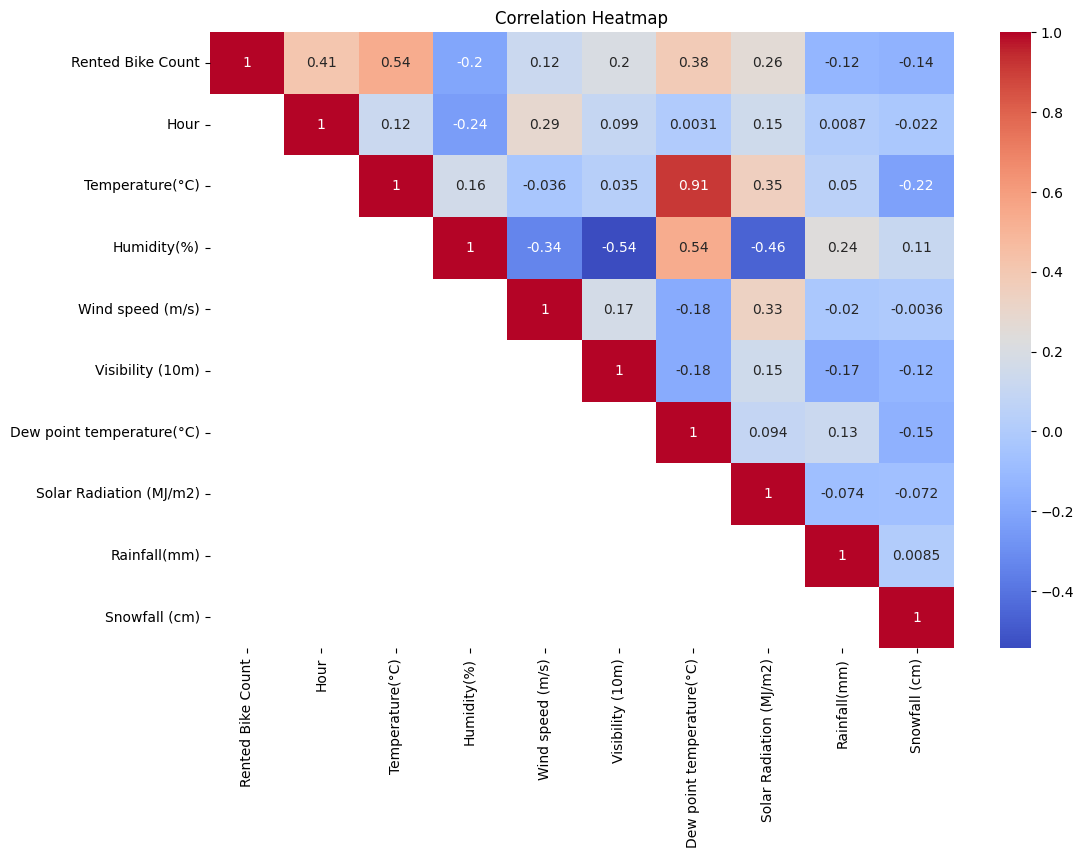

In [ ]:
corr = df.corr(numeric_only=True)
mask = np.tril(np.ones_like(corr, dtype=bool), k=-1)
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', mask=mask)
plt.title('Correlation Heatmap')
plt.show()

**Q1 — Why did you pick this chart?**

I chose a heatmap because it visually represents correlations between numeric variables, making relationships easy to identify.

**Q2 — What insights were found?**

The chart highlights strong positive or negative correlations, helping identify which factors influence bike rentals.

**Q3 — Business impact ?**

Yes, understanding relationships helps improve predictive analysis, planning, and decision-making.

#**Solution to Business Objective**

**The analysis of the bike rental dataset helps understand how time, weather, and seasonal factors influence rental demand. By identifying peak hours, favorable weather conditions, and seasonal trends, the business can optimize bike availability, staffing, and maintenance schedules.**

**These insights support better demand forecasting, reduce operational inefficiencies, and improve customer satisfaction. Ultimately, data-driven planning enables the company to maximize revenue while ensuring smooth service operations**

#**Conclusion**

**The bike rental data analysis reveals clear patterns influenced by time, weather, and seasonal conditions. Peak rental hours, favorable temperatures, and operational days significantly impact demand.**

**Understanding these trends enables smarter decision-making, efficient resource allocation, and improved customer service. Overall, data-driven insights help the business enhance performance, planning, and profitability.**